# Initialize Notebook

---

In [2]:
# Package imports
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Importing the classes and helper functions from the PRIZM files
from src.PRIZM_classes import ZeroShotModellerModule, PlottingModule

In [3]:
# Initialize PRIZM
model_list = ['CARP','ESM1b','ESM1v','ESM2','Progen2','ProtGPT2','RITA','TranceptionNoRet','UniRep', #Sequence
              'eUniRep','EVE','GEMME','TranceptEVE','Tranception', 'MSATransformer', #MSA
              'ESM-IF1','MIF','MIFST','MULAN','ProteinMPNN','ProSST','ProtSSN','SaProt',#Structure
              'RSALOR','VenusREM', #all,
              ]
prizm = ZeroShotModellerModule('src/model_config.yaml') # Initialize the PRIZM ZeroShotModeller module
prizmplt = PlottingModule() # Initialize the plotting module

---

# Model Selection - Low-N Dataset

In the Model Selection phase of the PRIZM pipeline, the zero-shot scores of a Low-N dataset is compared to its experimental values. Importantly, this requires all the specified ZS predictors to have been run for the given dataset. The Model Selection workflow will then be able to calculate the correlation metrics for every model and use these metrics to identify the best and worst overall models, as well as the best and worst models for each input category (Sequence, MSA, Structure).

## Load dataset

The data is loaded into the ZeroShotModeller module for future processing. Please specify datafile name and WT threshold, as well as the directory contained the ZS results.

---

In [4]:
# Change the values of the following variables as needed. You can add more names and thresholds to the lists as needed, but make sure they are in the same order (i.e. the first name corresponds to the first threshold, etc.)
lowN_name = ['TOGT1_1_relact']
wt_threshold = [47.87383674]

In [5]:
for name,wt_thresh in zip(lowN_name, wt_threshold):
    prizm.set_threshold(name,wt_thresh)
    prizm.load_scores(name,model_list)

---

## Process dataset

In this section, the correlation metrics are calculated, and the best/worst models are identified. Please not that the metrics used to identify the best/worst models are Spearman Correlation and Average Precision by default. If a different metric is desired, please see PRIZM documentation for how to do this.

The Low-N dataset of TOGT1_1 is here used as an example.



---

In [1]:
# Change the values of the following variables as needed
n_bootstrap = 1000 # Decrease to reduce computation time

In [42]:
for name in lowN_name:
    prizm.compute_metrics(name,n_bootstrap=n_bootstrap, metrics = ['spearmanr','average_precision'])
    prizm.process_models(name)

In [12]:
prizm.worst_models_correct

{'TOGT1_1_relact': {'overall': 'MIF',
  'sequence': 'UniRep',
  'structure': 'MIF',
  'MSA': 'eUniRep',
  'all': 'RSALOR'}}

In [16]:
# Print the best and worst models for each category and the overall best model for each dataset
for name in lowN_name:
    print('Results for',name)
    best_models = [prizm.best_models[name][cat] for cat in ['overall','sequence','MSA','structure','all']]
    worst_models = [prizm.worst_models[name][cat] for cat in ['overall','sequence','MSA','structure','all']]
    print('Best Overall Model:',best_models[0])
    print('Best Sequence Model:',best_models[1])
    print('Best MSA Model:',best_models[2])
    print('Best Structure Model:',best_models[3])
    print('---------------------------------')
    print('Worst Overall Model:',worst_models[0])
    print('Worst Sequence Model:',worst_models[1])
    print('Worst MSA Model:',worst_models[2])
    print('Worst Structure Model:',worst_models[3])

print('---------------------------------')
print('\n')
print('---------------------------------')

# We can also do the same for only the models with correct sign of correlation
for name in lowN_name:
    print('Results for',name,'- only models with correct sign of correlation')
    best_models = [prizm.best_models_correct[name][cat] for cat in ['overall','sequence','MSA','structure','all']]
    worst_models = [prizm.worst_models_correct[name][cat] for cat in ['overall','sequence','MSA','structure','all']]
    print('Best Overall Model:',best_models[0])
    print('Best Sequence Model:',best_models[1])
    print('Best MSA Model:',best_models[2])
    print('Best Structure Model:',best_models[3])
    print('---------------------------------')
    print('Worst Overall Model:',worst_models[0])
    print('Worst Sequence Model:',worst_models[1])
    print('Worst MSA Model:',worst_models[2])
    print('Worst Structure Model:',worst_models[3])

Results for TOGT1_1_relact
Best Overall Model: VenusREM_4096
Best Sequence Model: ESM2_150M
Best MSA Model: Tranception_L
Best Structure Model: ProSST_1024
---------------------------------
Worst Overall Model: MIF
Worst Sequence Model: ProtGPT2
Worst MSA Model: GEMME
Worst Structure Model: MIF
---------------------------------


---------------------------------
Results for TOGT1_1_relact - only models with correct sign of correlation
Best Overall Model: VenusREM_4096
Best Sequence Model: CARP_76M
Best MSA Model: eUniRep
Best Structure Model: ProSST_1024
---------------------------------
Worst Overall Model: MIF
Worst Sequence Model: UniRep
Worst MSA Model: eUniRep
Worst Structure Model: MIF


If needed, the scores of the best models can be saved in a file together with the raw DMS score

In [ ]:
# Extract mutant information and DMS scores from experimental data
data_ = prizm.datasets[lowN_name]['exp_data'][['mutant','DMS_score']]

# Iterate through the best models and merge the predictions with the experimental data
for key,item in prizm.best_models[lowN_name].items():
    if key != 'overall': # Skip the overall model to avoid duplicate columns
        data_ = pd.merge(data_,prizm.datasets[lowN_name][item][['mutant',item]],on='mutant',how='inner')

# Save the data to a CSV file
data_.to_csv(f'../results/{lowN_name}_best_models_with_exp.csv',index=False)

---

## Plot results

In this section, correlation results are plotted. This includes a comparison of the performance of all models, as well as the performance of singular models. Again, please note that the default metrics are Spearman Correlation and Average Precision. See PRIZM documentation for how to change this. Furthermore, please specify the folder for saving the metric figures.

---

Metrics for TOGT1_1_relact, using all models:


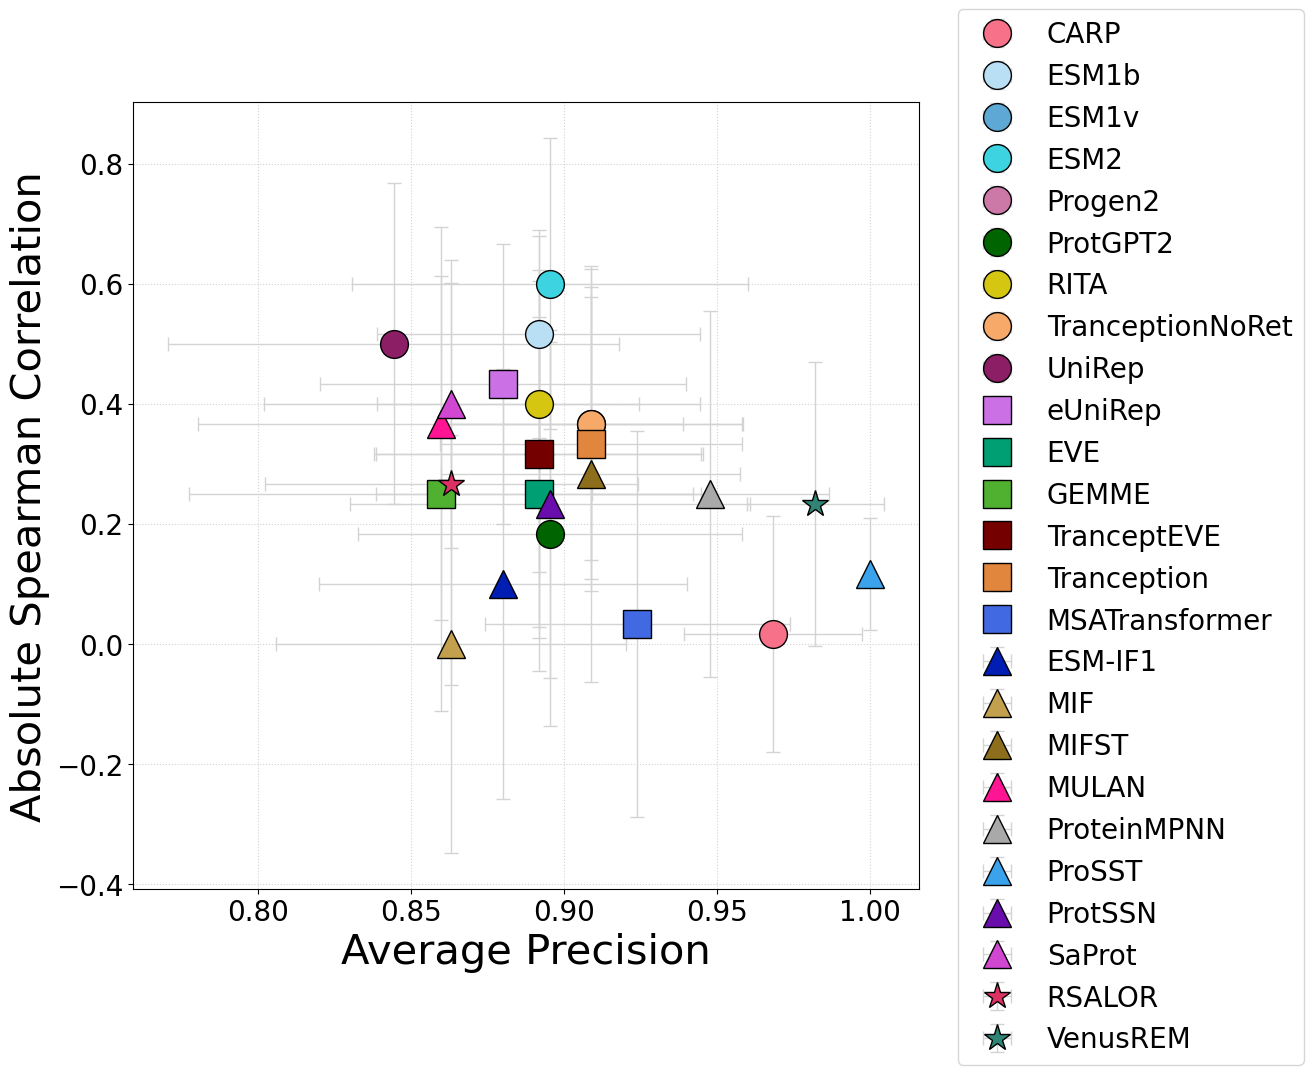

Metrics for TOGT1_1_relact, using only correct models


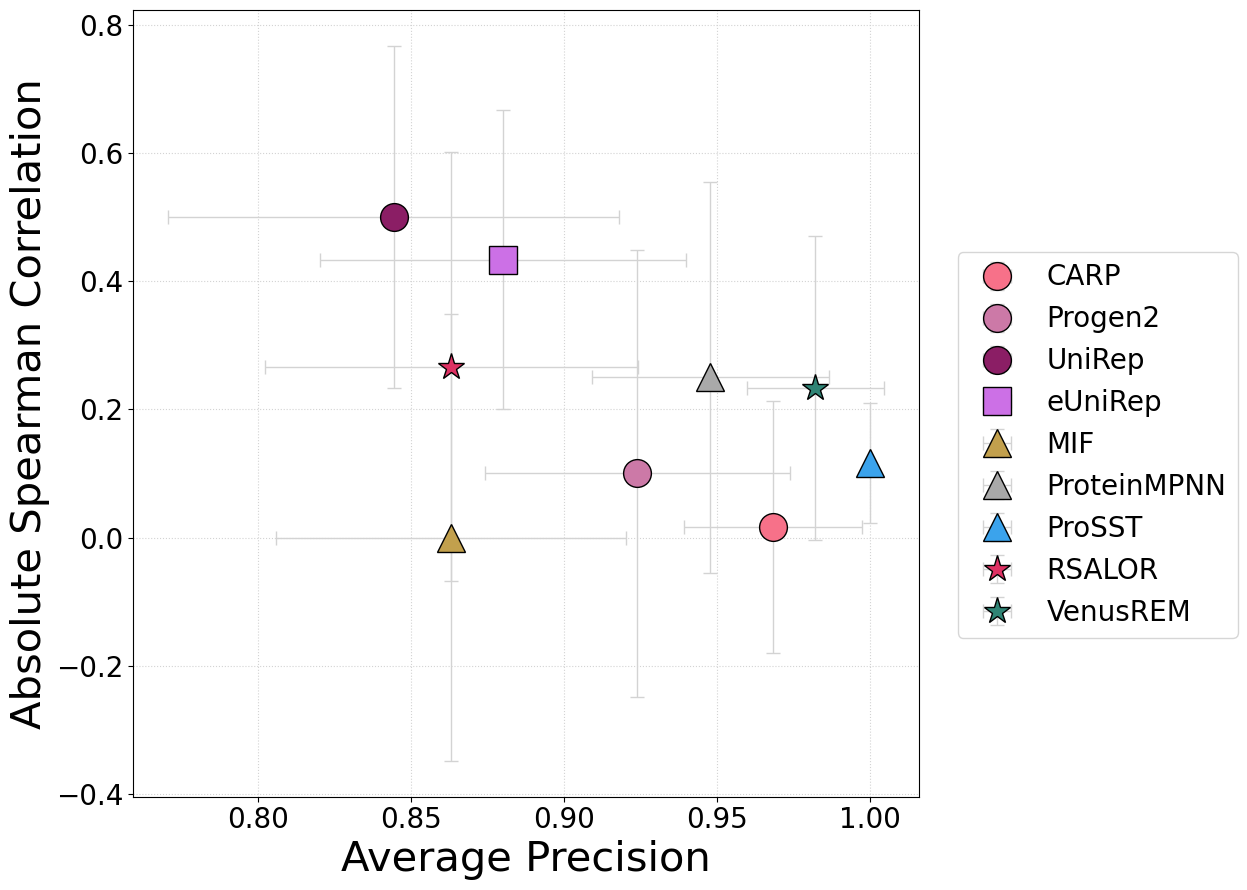

In [17]:
# Plotting the model performances, using either all models or just the ones with correct sign of correlation
for name in lowN_name:
    print(f'Metrics for {name}, using all models:')
    prizmplt.metrics(prizm, name)
    print(f'Metrics for {name}, using only correct models')
    prizmplt.metrics(prizm, name, use_correct=True)

Highlighting metrics for TOGT1_1_relact, using all models:


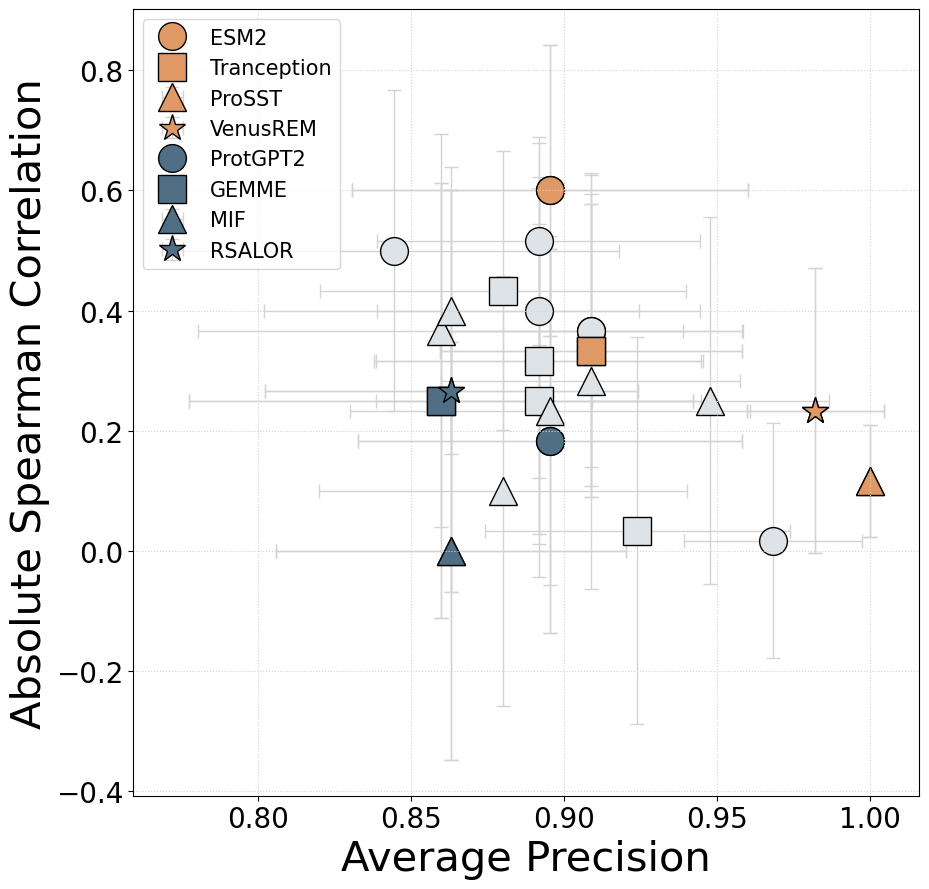

Highlighting metrics for TOGT1_1_relact, using only correct models


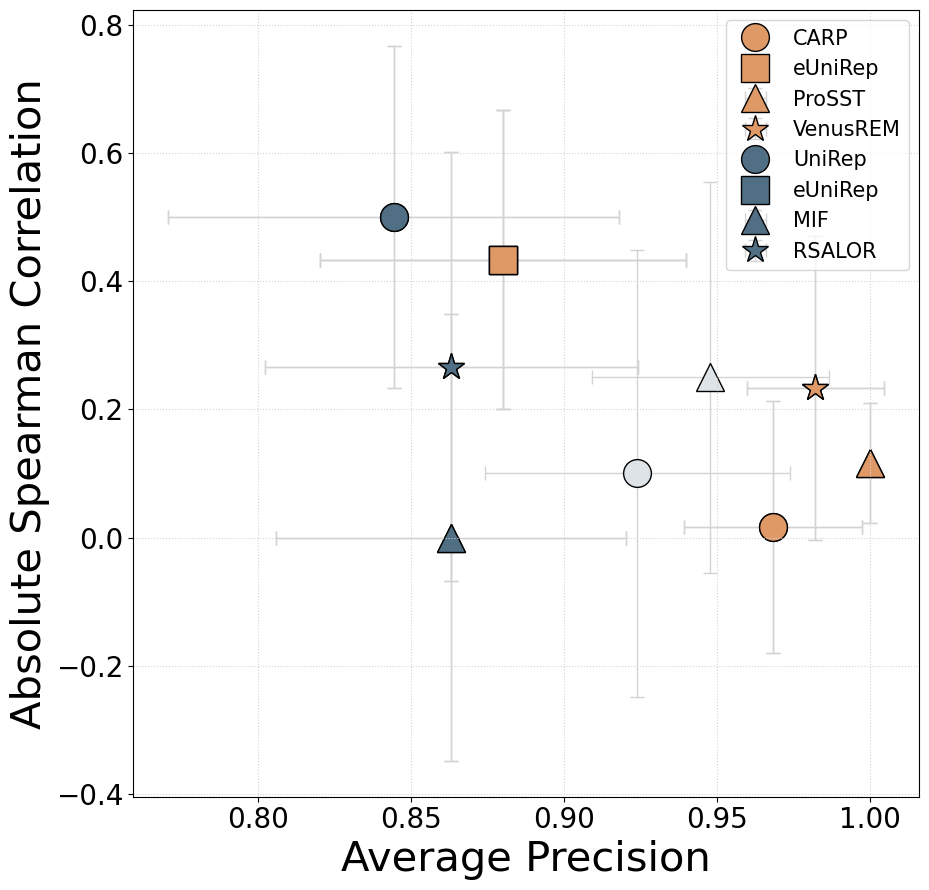

In [18]:
# Plotting the model performances, with the best and worst models highlighted
for name in lowN_name:
    print(f'Highlighting metrics for {name}, using all models:')
    prizmplt.metrics_cat(prizm, name)
    print(f'Highlighting metrics for {name}, using only correct models')
    prizmplt.metrics_cat(prizm, name, use_correct=True)

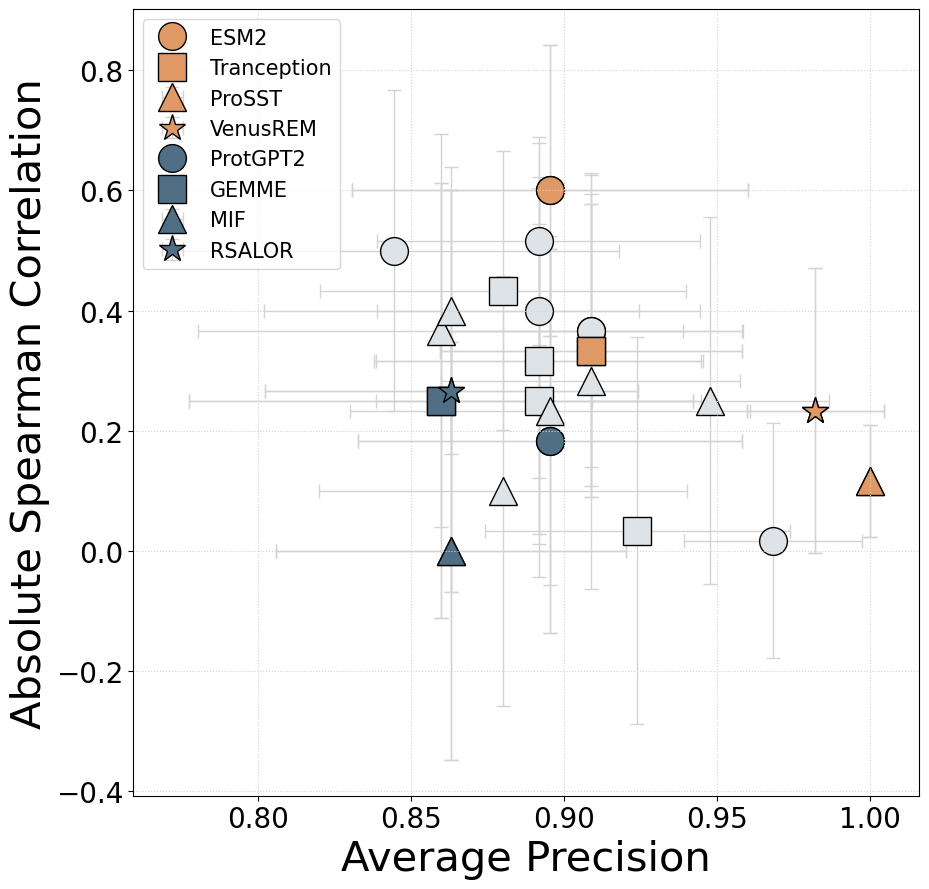

In [19]:
# The plot can also be saved in SVG format for better resolution
prizmplt.metrics_cat(prizm, lowN_name[0], format='svg')

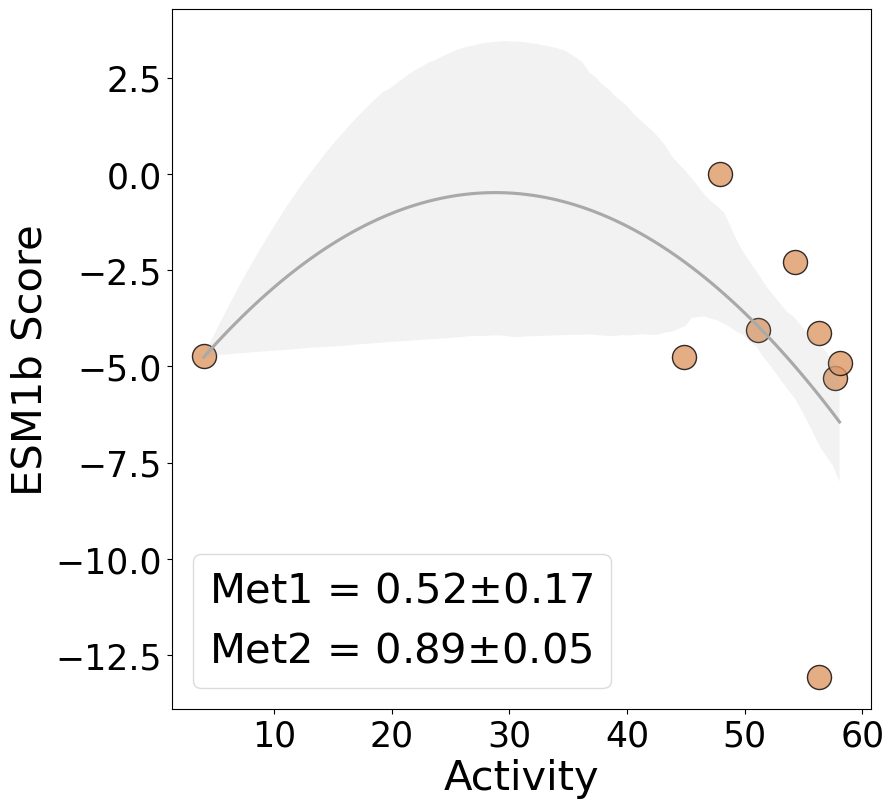

In [41]:
# Plotting the performance of individual models against the experimental data
# Met1 = Absolute Spearman correlation
# Met2 = Average Precision
model_name = 'ESM1b'
score_name = 'ESM1b'
exp_property = 'Activity'
for name in lowN_name:
    prizmplt.zs_vs_exp_scatter(prizm,name,model_name,custom_zsname=score_name,custom_expname=exp_property, format='svg')

Plotting results for TOGT1_1_relact
Overall Model
Best Overall Model: VenusREM_4096


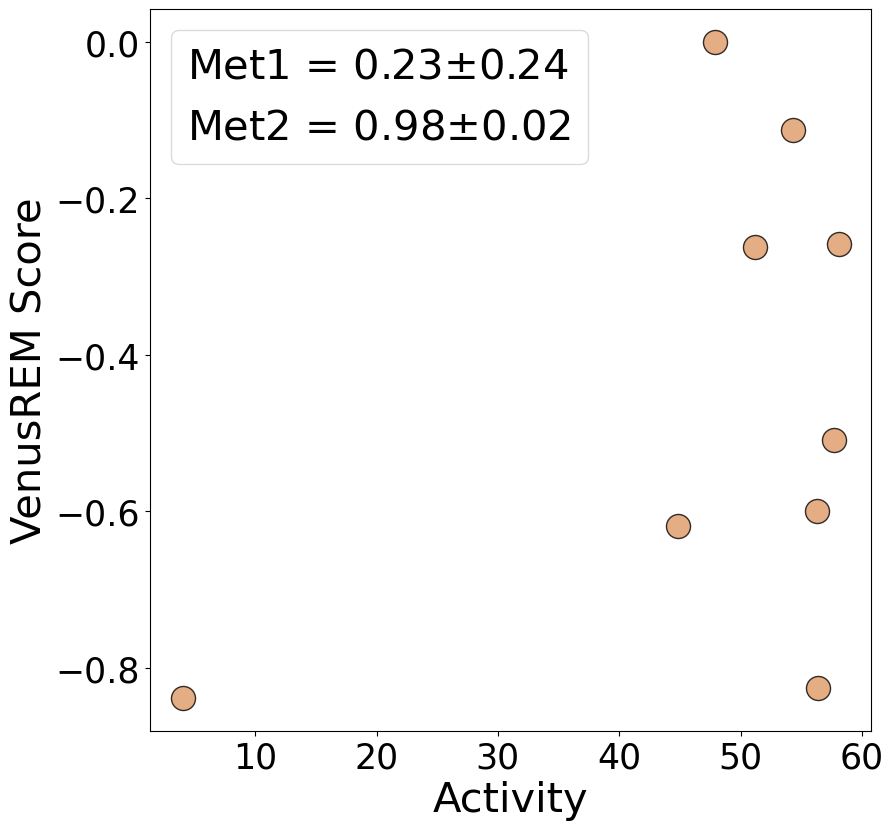

Worst Overall Model: MIF


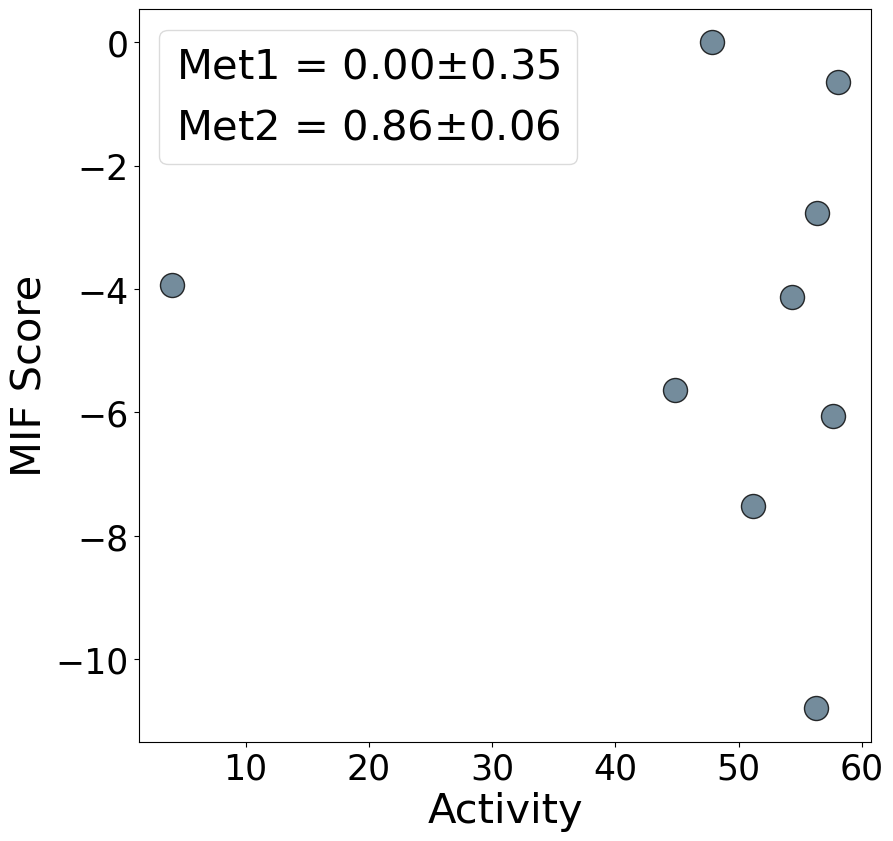

Sequence Model
Best Sequence Model: ESM2_150M


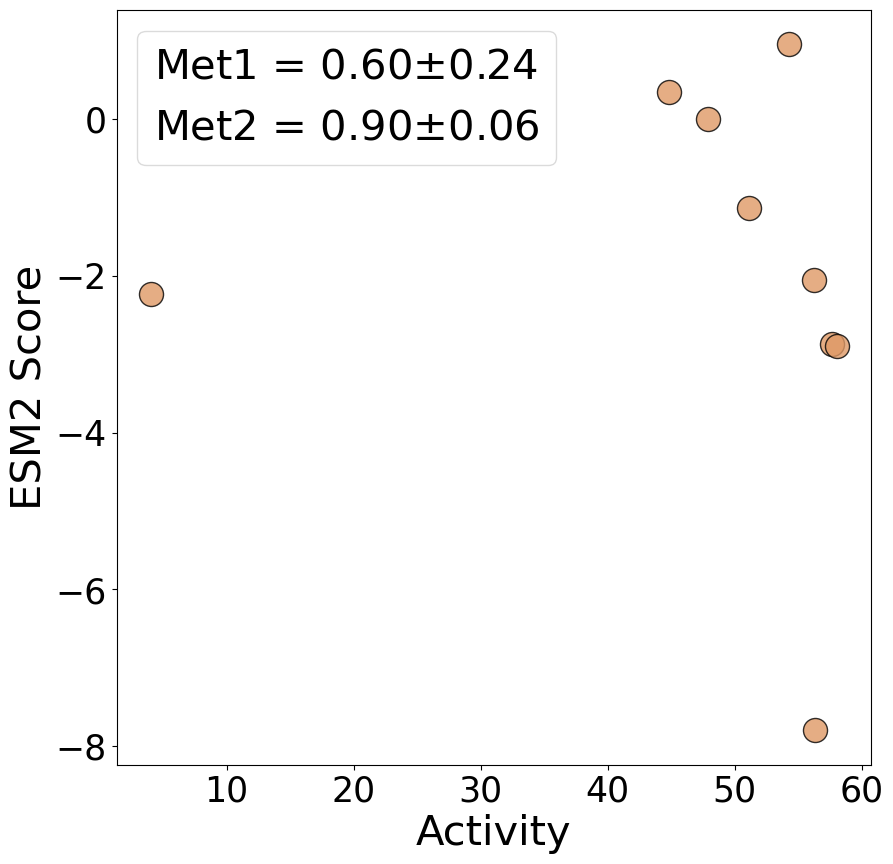

Worst Sequence Model: ProtGPT2


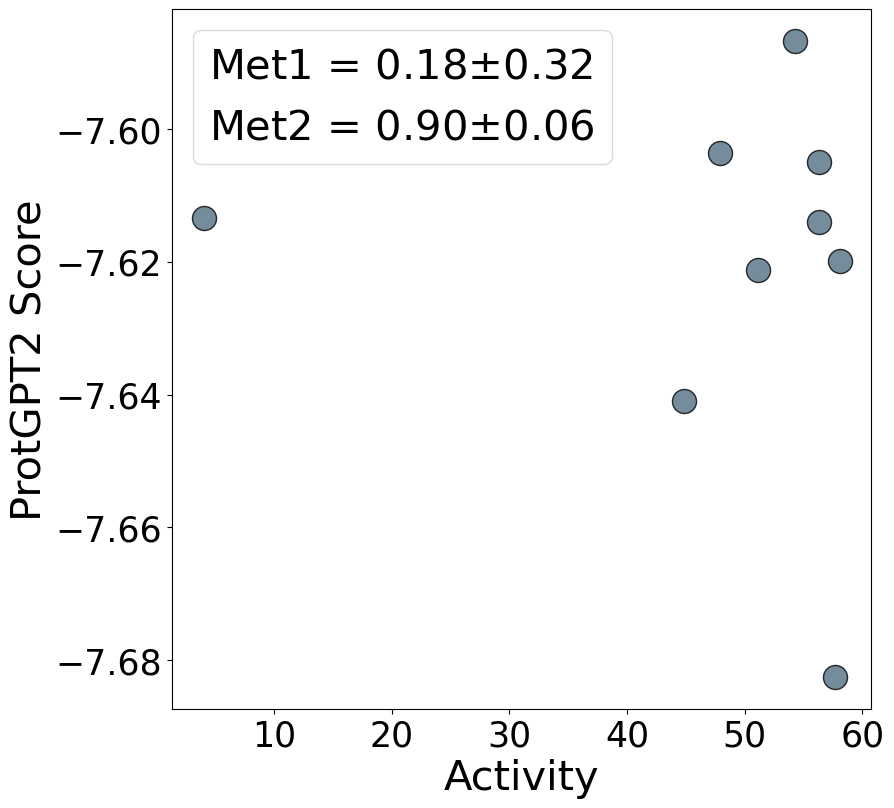

MSA Model
Best MSA Model: Tranception_L


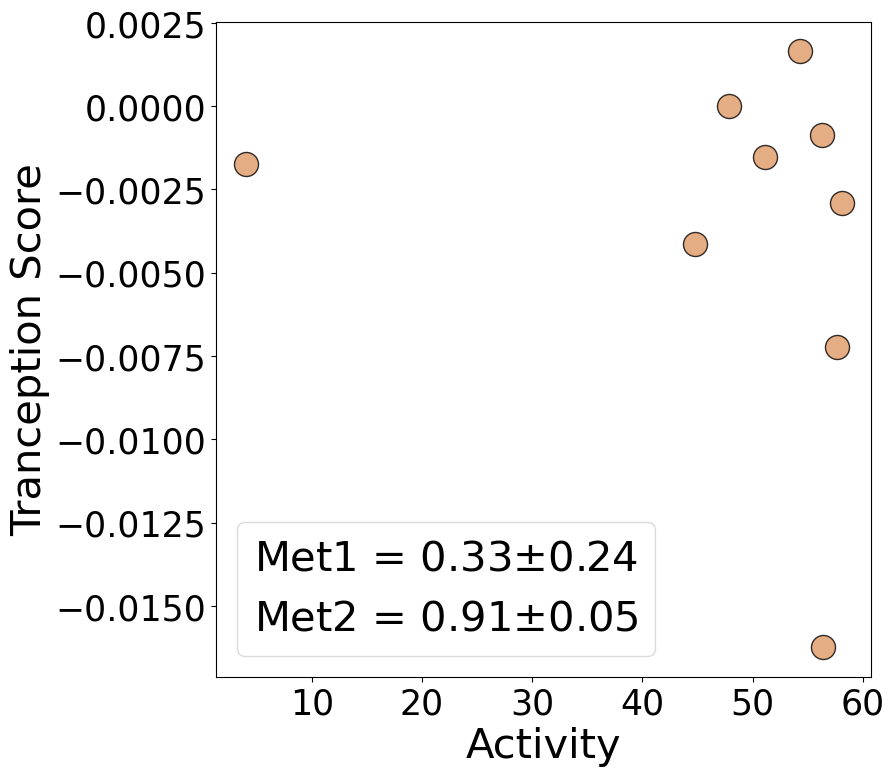

Worst MSA Model: GEMME


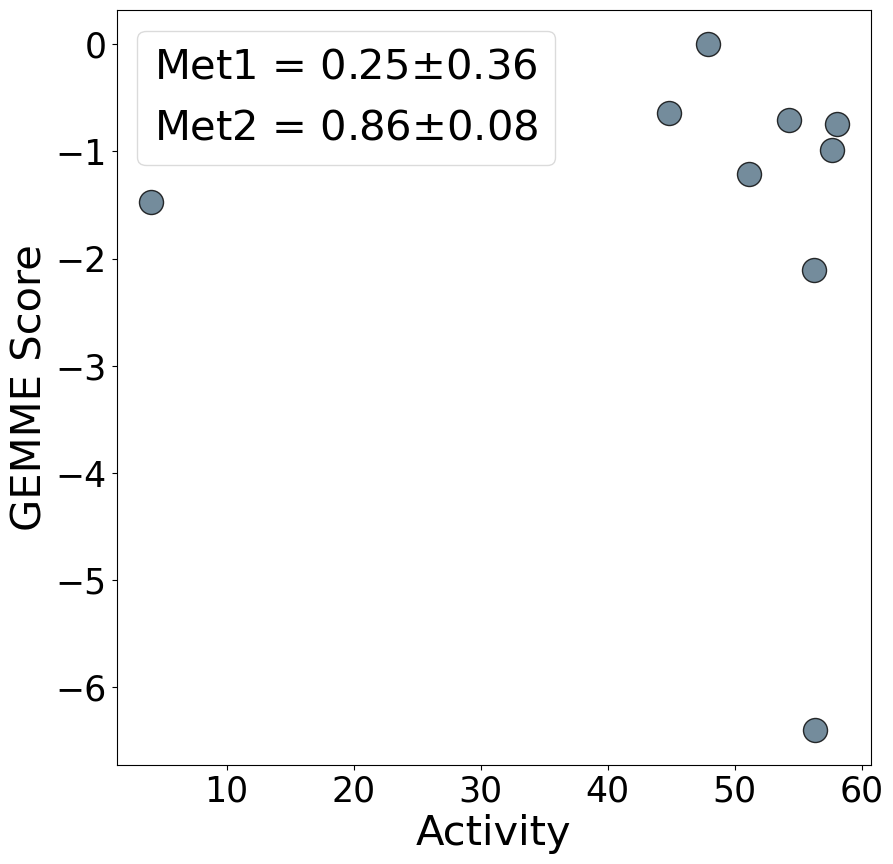

Structure Model
Best Structure Model: ProSST_1024


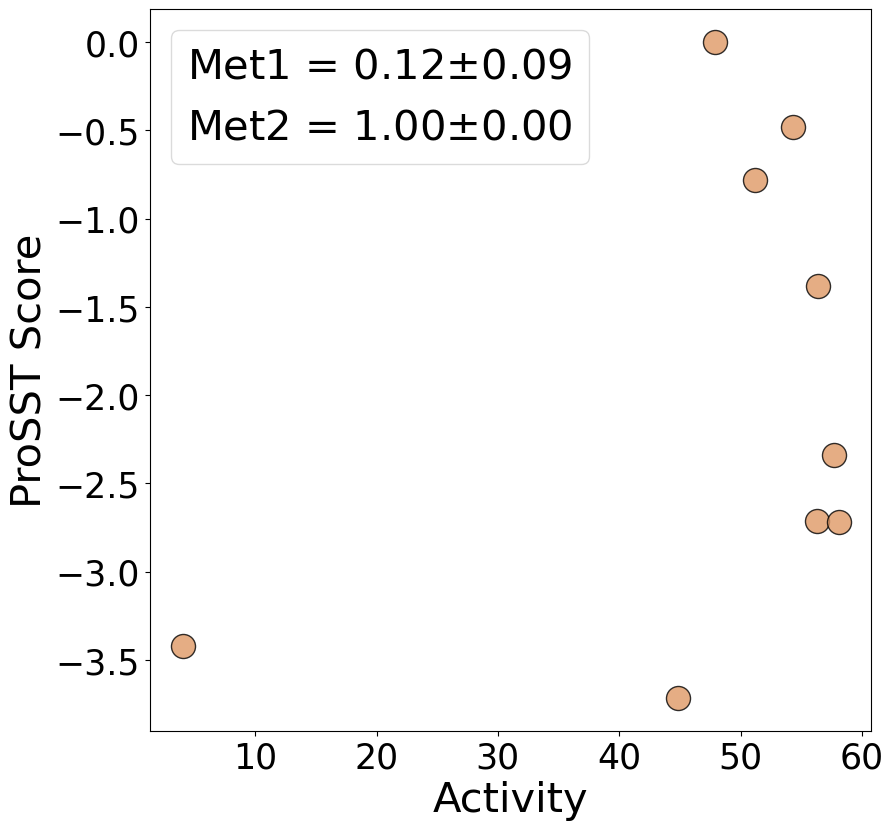

Worst Structure Model: MIF


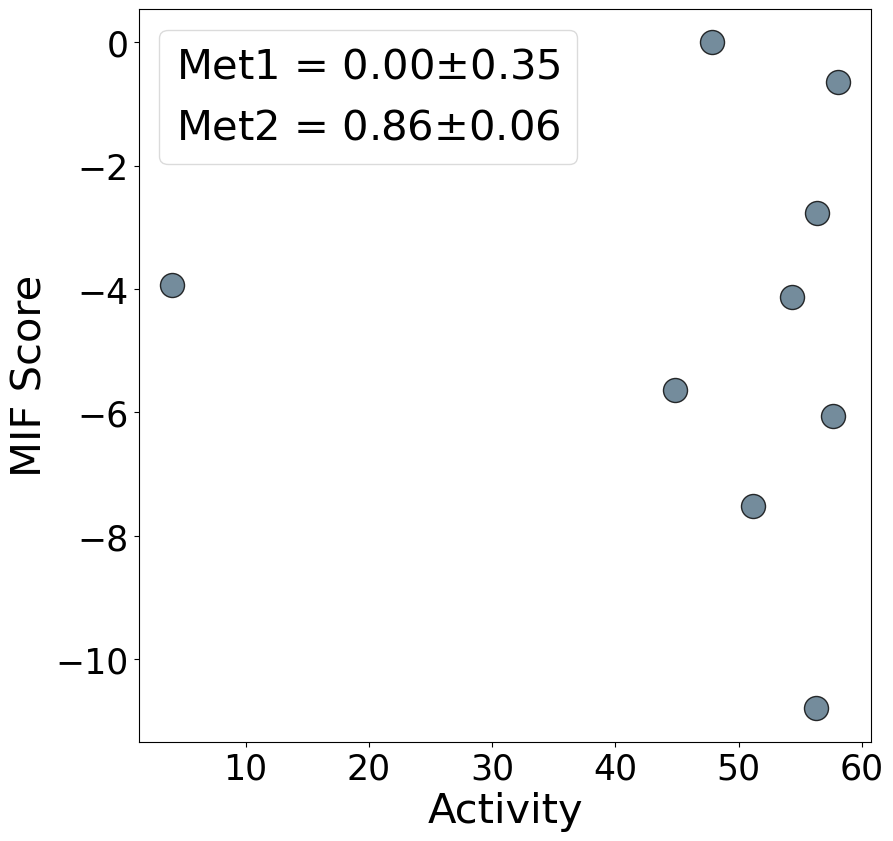

All features
Best Model using all features: VenusREM_4096


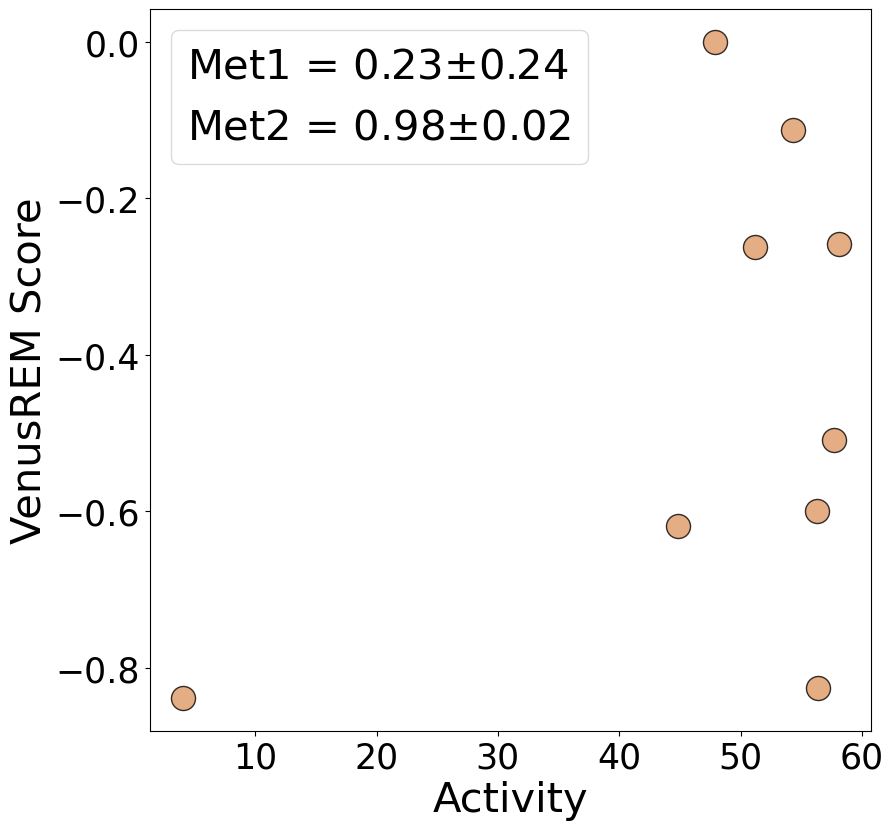

Worst Model using all features: RSALOR


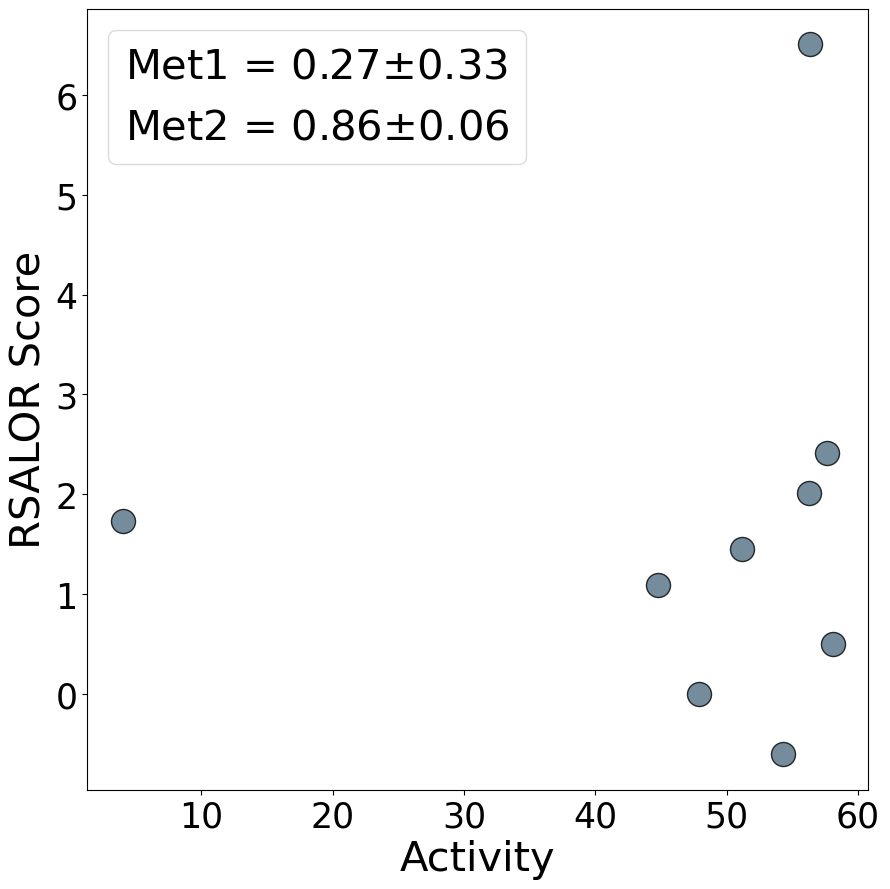

In [23]:
# Plotting the performance of the best and worst models
# Met1 = Absolute Spearman correlation
# Met2 = Average Precision
exp_property = 'Activity'
worst_color = '#516f84'
for name in lowN_name:
    print(f'Plotting results for {name}')

    print('Overall Model')
    best_ = prizm.best_models[name]['overall']
    best_score_name = best_.split('_')[0]
    worst_ = prizm.worst_models[name]['overall']
    worst_score_name = worst_.split('_')[0]
    print('Best Overall Model:',best_)
    prizmplt.zs_vs_exp_scatter(prizm,name,best_,custom_zsname=best_score_name,custom_expname=exp_property, format='png',reg_plot=False)
    print('Worst Overall Model:',worst_)
    prizmplt.zs_vs_exp_scatter(prizm,name,worst_,custom_zsname=worst_score_name,custom_expname=exp_property, color=worst_color,format='png',reg_plot=False)

    print('Sequence Model')
    best_ = prizm.best_models[name]['sequence']
    best_score_name = best_.split('_')[0]
    worst_ = prizm.worst_models[name]['sequence']
    worst_score_name = worst_.split('_')[0]
    print('Best Sequence Model:',best_)
    prizmplt.zs_vs_exp_scatter(prizm,name,best_,custom_zsname=best_score_name,custom_expname=exp_property, format='png',reg_plot=False)
    print('Worst Sequence Model:',worst_)
    prizmplt.zs_vs_exp_scatter(prizm,name,worst_,custom_zsname=worst_score_name,custom_expname=exp_property, color=worst_color,format='png',reg_plot=False)

    print('MSA Model')
    best_ = prizm.best_models[name]['MSA']
    best_score_name = best_.split('_')[0]
    worst_ = prizm.worst_models[name]['MSA']
    worst_score_name = worst_.split('_')[0]
    print('Best MSA Model:',best_)
    prizmplt.zs_vs_exp_scatter(prizm,name,best_,custom_zsname=best_score_name,custom_expname=exp_property, format='png',reg_plot=False)
    print('Worst MSA Model:',worst_)
    prizmplt.zs_vs_exp_scatter(prizm,name,worst_,custom_zsname=worst_score_name,custom_expname=exp_property, color=worst_color,format='png',reg_plot=False)

    print('Structure Model')
    best_ = prizm.best_models[name]['structure']
    best_score_name = best_.split('_')[0]
    worst_ = prizm.worst_models[name]['structure']
    worst_score_name = worst_.split('_')[0]
    print('Best Structure Model:',best_)
    prizmplt.zs_vs_exp_scatter(prizm,name,best_,custom_zsname=best_score_name,custom_expname=exp_property, format='png',reg_plot=False)
    print('Worst Structure Model:',worst_)
    prizmplt.zs_vs_exp_scatter(prizm,name,worst_,custom_zsname=worst_score_name,custom_expname=exp_property, color=worst_color,format='png',reg_plot=False)

    print('All features')
    best_ = prizm.best_models[name]['all']
    best_score_name = best_.split('_')[0]
    worst_ = prizm.worst_models[name]['all']
    worst_score_name = worst_.split('_')[0]
    print('Best Model using all features:',best_)
    prizmplt.zs_vs_exp_scatter(prizm,name,best_,custom_zsname=best_score_name,custom_expname=exp_property, format='png',reg_plot=False)
    print('Worst Model using all features:',worst_)
    prizmplt.zs_vs_exp_scatter(prizm,name,worst_,custom_zsname=worst_score_name,custom_expname=exp_property, color=worst_color,format='png',reg_plot=False)

---

### Custom Plots

This section is for making custom plots, that is not suppported by the PRIZM Class.

Below you can find plots that we used for the publication: Data-efficient distal engineering of fluorinase using zero-shot models

---

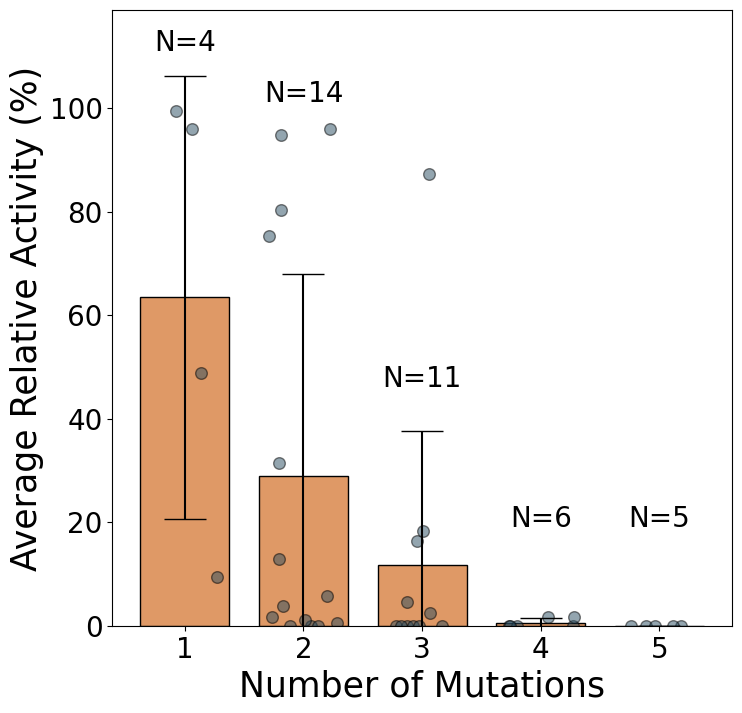

In [ ]:
# Plotting the average DMS score for a specific number of mutations in a single variant

# Initialize the figure and parameters
fig, ax = plt.subplots(1,1,figsize=(8,8))
X = np.arange(1,6)
text_y = [110,100,45,18,18]

# Set the random seed for reproducibility
np.random.seed(42)

# Plot the average DMS score per number of mutations
ax.bar(X,[prizm.datasets[lowN_name]['exp_data'].DMS_score[prizm.datasets[lowN_name]['exp_data'].mutant.str.count(':')==i].mean() for i in np.arange(5)],
       yerr=[prizm.datasets[lowN_name]['exp_data'].DMS_score[prizm.datasets[lowN_name]['exp_data'].mutant.str.count(':')==i].std() for i in np.arange(5)],
       color='#DF9966',width=0.75,edgecolor='k',capsize=15)

# Plot the individual data points
for i in range(5):
    val = prizm.datasets[lowN_name]['exp_data'].DMS_score[prizm.datasets[lowN_name]['exp_data'].mutant.str.count(':')==i].values
    ax.scatter(X[i]+np.random.uniform(low=-0.3,high=0.3,size=len(val)),val,color='#294C60',edgecolor='k',s=70,alpha=0.5)
    
    # Annotate the number of data points
    ax.text(X[i],text_y[i],f'N={len(val)}',ha='center',va='bottom',fontsize=20)

# Set the label parameters and limits
ax.set_xlabel('Number of Mutations', fontsize=25)
ax.set_ylabel('Average Relative Activity (%)', fontsize=25)
ax.tick_params(labelsize=20)
ax.set_ylim(0,119)

# Save and display the plot
plt.savefig('../figures/DMS_score_vs_num_mutations.svg',dpi=300)
plt.show()

In [6]:
# Load animo acid order and index from the PRIZM package and create color dictionary
from src.PRIZM_classes import aa_order, aa_to_index
count_colors_dict = {1: '#294C60', 2: '#0077CC', 3: '#ADB6C4', 4: '#F2D0A4', 5: '#DF9966'}

# Initialize a dictionary to store unique mutations by position
mutations_dict = {}

# Extract the mutant information
mutant_data = prizm.datasets[lowN_name]['exp_data'].mutant

# Iterate over all mutant information
for mutants in mutant_data:

    # Split by ":" to extract individual mutations
    mutations = mutants.split(":")

    # Iterate over all individual mutations
    for mutation in mutations:

        # Parse the mutation (e.g., E247G -> WT=E, Pos=247, Mut=G)
        match = re.match(r"([A-Z])(\d+)([A-Z])", mutation)

        # If the mutation is valid, store the mutant
        if match:
            wt, pos, mut = match.groups()

            # Initialize a list to store the mutations at each position if it does not exist
            if wt+pos not in mutations_dict:
                mutations_dict[wt+pos] = []
            
            # For every site, store the mutations that have been observed
            mutations_dict[wt+pos].append(mut)

# Extract the unique mutations and their indices, as well as the name of the sites
sites = list(mutations_dict.keys())
unique_mutations = [np.unique(mutations_dict[site]) for site in sites]
unique_mutations_idx = [[aa_to_index[m] for m in unique_mutations[i]] for i in range(len(unique_mutations))]

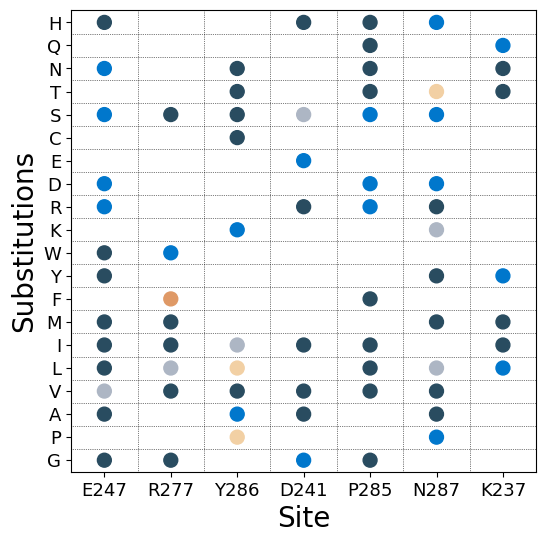

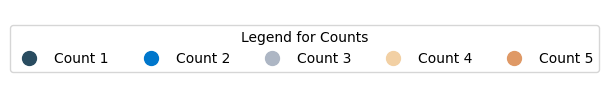

In [7]:
# Create a figure for showing number of unique mutations by site

# Initialize the figure and parameters
fig, ax = plt.subplots(1,1,figsize=(6,6))


# Iterate over all sites and plot the number of unique mutations
for s,site in enumerate(sites):

    # Count the number of occurrences of each unique mutation at a site
    count_mutations = [np.sum([mutations_dict[site][i]==M for i in range(len(mutations_dict[site]))]) for M in unique_mutations[s]]
    
    # Plot the unique mutations at a site and color them by the count
    ax.scatter([sites[s]]*len(unique_mutations[s]),unique_mutations_idx[s],c=[count_colors_dict[count] for count in count_mutations],s=100)

# Set the label parameters, grid lines, and limits
ax.set_xlabel('Site', fontsize=20)
ax.set_ylabel('Substitutions', fontsize=20)
ax.set_yticks(range(len(aa_order)))
ax.set_yticklabels(aa_order)
ax.tick_params(labelsize=13)
for i in range(len(aa_order)-1):
    ax.axhline(i+0.5, color='black', ls=':', lw=0.5)
for i in range(len(sites)-1):
    ax.axvline(i+0.5, color='black', ls=':', lw=0.5)
ax.set_xlim(-0.5,len(sites)-0.5)
ax.set_ylim(-0.5,len(aa_order)-0.45)

# Save and display the plot
plt.savefig('../figures//unique_mutations_by_site.svg',dpi=300)
plt.show()


# Create new figure for showing the legend
fig, ax = plt.subplots(figsize=(6, 1))

# Remove the axis and create a legend for the counts
ax.axis('off')
legend_handles = [
    plt.Line2D([0], [0], marker='o', color=color, label=f'Count {count}', 
               markersize=10, linestyle='None') 
    for count, color in count_colors_dict.items()
]

# Add the legend to the plot and display it
ax.legend(handles=legend_handles, loc='center', title="Legend for Counts", ncol=len(count_colors_dict))
plt.show()

---

# Variant Ranking - In-silico Library

After having identified the best models, we can use them to score the mutants of an in silico library. This section assumes that the user has already obtained the ZS scores for the mutants of interest. If this hasn't been done, please run the "Make in-silico library" section and run the PRIZM calculation pipeline for the best models.

## Make in-silico library

The code below demonstrates how to use the best models to score the mutants of an in silico library. The full single-mutant landscape for TOGT1_1 is here used as an example

---

In [28]:
# Change the values of the following variables as needed
dataset_name = 'TOGT1_1'
library_suffix = 'SMscan'
numb_mut = [1] # For both single and double mutants, use the format [1,2]. We recommend using only single mutants for the in silico library
mut_sites = None # For specific sites, use the format [10,25,50]. We recommend using all sites (None) for the in silico library
exclude_aa = None # For excluding specific amino acids, use the format ['C','W']. We recommend not excluding any amino acids (None) for the in silico library
exclude_sites = None # For excluding specific sites, use the format [10,25,50]. We recommend not excluding any sites (None) for the in silico library

# Define the wild-type sequence of the protein of interest. This is needed for generating the in silico library and for computing the scores for the variants in the DMS dataset. Make sure to use the one-letter amino acid codes and to match the sequence used in the DMS experiment.
wt_seq = 'MGQLHFFFFPMMAHGHMIPTLDMAKLVASRGVKATIITTPLNESVFSKSIQRNKYLGIEIEIRLIKFPAVENDLPEECERLDQIPSDDKLSNFFKATAMMQEPLEQLIEECRPNCLVSDMFLPWTTDSAAKFNIPRIVFHGTSFFALCVENSVRLNKPYKNVSSDAETFVVPNLPHEIKLTRTQLSPFEQSGEETAMTRMIKTVRESDSKSYGVVFNSFYELETDYVEHYTKVLGRRAWAIGPLSMCNRDIEDKAERGKKSSIDKHECLKWLDSKKPSSVVYVCFGSVANFTASQLHELAMGIEASGQEFIWVVRTELDNEDWLPEGFEERTKEKGLIIRGWAPQVLILDHESVGAFVTHCGWNSTLEGVSGGVPMVTWPVFAEQFFNEKLVTEVLKTGAGVGSIQWKRSASEGVKREAIAKAIKRVMVSEEAEGFRNRAKAYKEMARKAVEEGGSSYTGLTTLLEDISTYTSTGH'

In [29]:
# Generate the insilico library
insilico_library = prizm.insilico_library(dataset_name,numb_mut,wt_seq=wt_seq,custom_name=library_suffix,
                                               mut_sites=mut_sites,exclude_aa=exclude_aa,exclude_sites=exclude_sites)

---

## In silico library analysis

### Load dataset

The in silico library ZS scores for the best models identified in the Variant Ranking phase is loaded. The same wildtype threshold is used as in the previous phase

---

In [32]:
# Change the values of the following variables as needed
dataset_name = 'TOGT1_1'
library_suffix = 'SMscan'
wt_threshold = 47.87383674
model_list_selection = ['VenusREM'] # Models for which the in silico library has been processed
library_name = dataset_name+'_'+library_suffix+'_insilico_library'

In [33]:
prizm.set_threshold(library_name,wt_threshold)
prizm.load_scores(library_name,model_list_selection,wt=True)

---

### Sort and Rank library

In this section, the in silico libraries are sorted and ranked based on the best models obtained from the Model Selection phase. This can be used to identify mutants for experimental validation.

It should be noted that the order of the ranking is based on maximizing the Spearman Correlation. Please see PRIZM documentation for how to change this


---

In [36]:
# Define which models to use for sorting the in silico library.
library_models = [prizm.best_models[lowN_name[0]]['overall']]

# The above line uses the best overall model for sorting the in silico library. You can also use the best models from each category (sequence, MSA, structure, all) by uncommenting the line below and commenting out the line above.
# library_models = [prizm.best_models[lowN_name][cat] for cat in ['sequence','MSA','structure','all']] # Best models from each category

# Define the overall best model
best_overall = prizm.best_models[lowN_name[0]]['overall'] # Best overall model, used for final sorting

In [37]:
# Sort the in silico library using the defined models and save the results to a CSV and XLSX file
library_ranking = prizm.sorting_mutants(library_name,library_models,best_overall,'../results/',wt=True)

---

### Single-Mutant Landscapes

PRIZM enables the user to generate and plot the full single-mutant landscape for a given model.

Again, TOGT1_1 is used as an example

---

In [38]:
# Change the values of the following variables as needed
landscape_rows = 4

In [39]:
# Generating the SM landscapes for the models in library_models
for model in library_models:
    prizm.sm_landscape(library_name,model,wt=True)

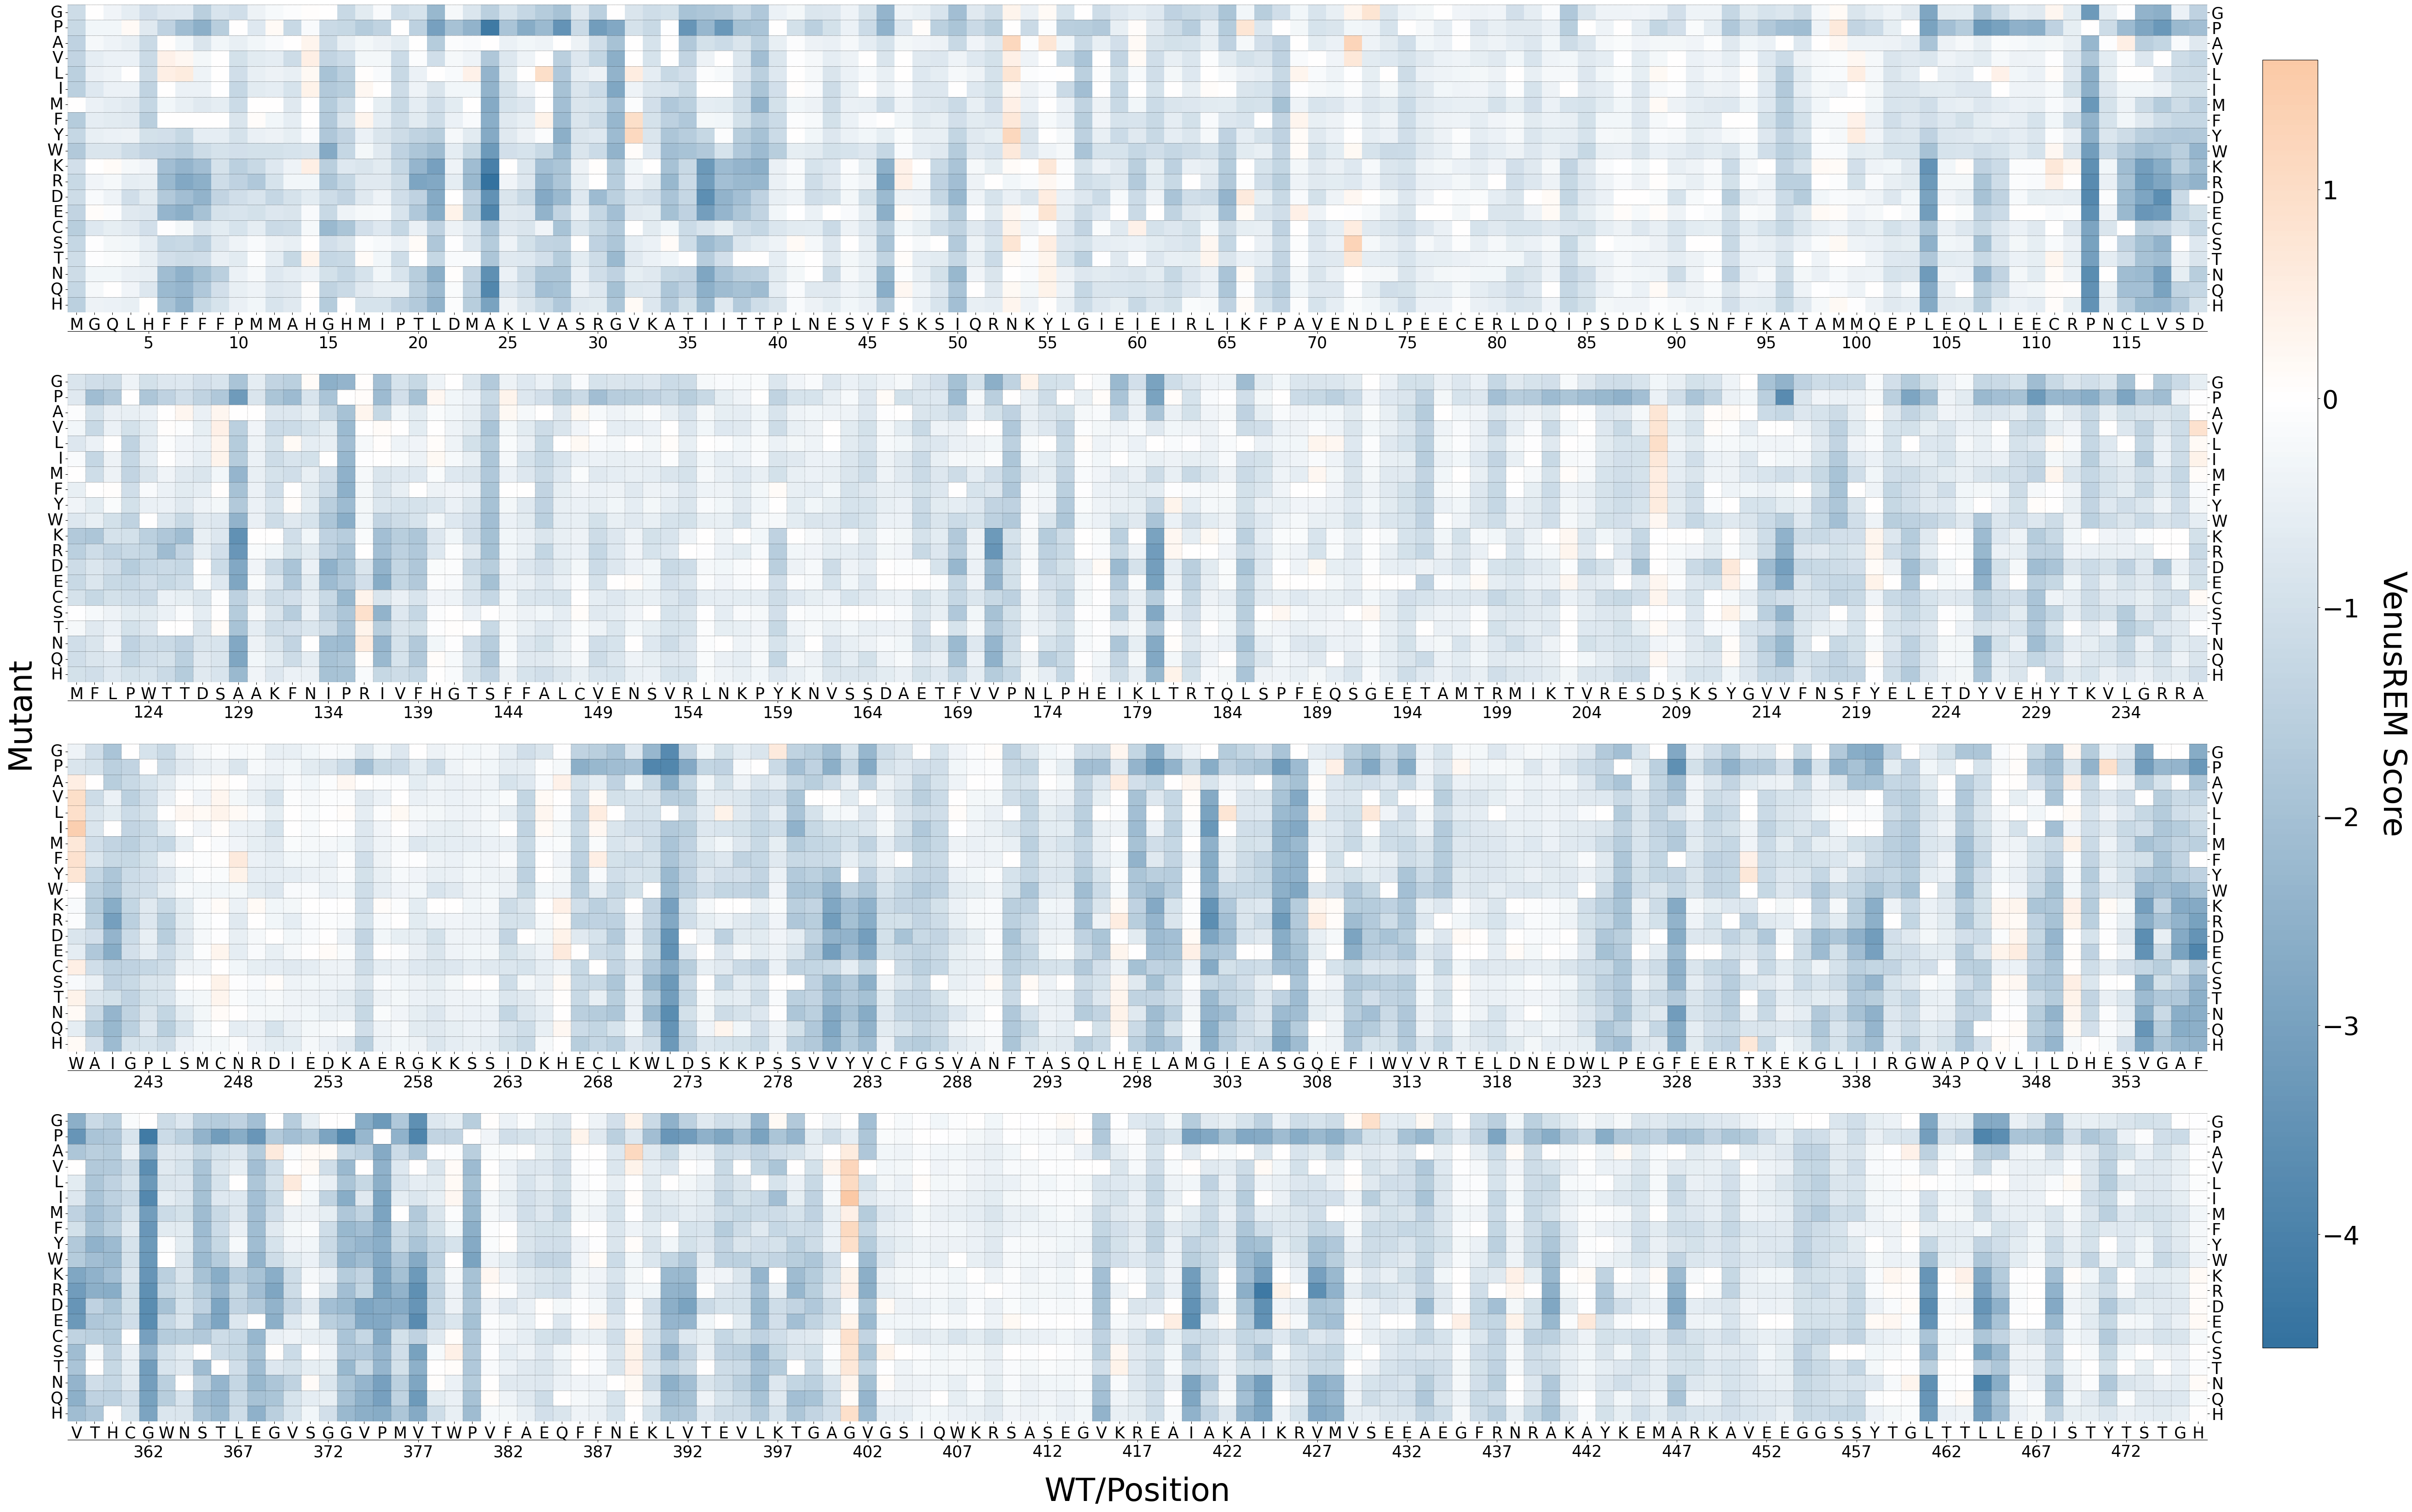

In [40]:
prizmplt.heatmap(prizm, library_name, 'VenusREM_4096', landscape_rows, 'VenusREM Score',alpha=1,
               colors=['#34729F', 'white', '#F36906'], format='png',figsize=(60, 40))